# Actividad - Solución Completa
## Procesamiento de Imágenes con OpenCV

Con las siguientes imágenes realiza las siguientes condiciones:

<img src="IMG/img1.jpg" alt="imagen 1" width="200">
<img src="IMG/img2.jpg" alt="imagen 1" width="200">

### Tareas:
1. ✓ Establece el fondo en rojo, azul, verde
2. ✓ Convertir a escala de grises
3. ✓ Convertir de BGR a RGB
4. ✓ Establecer un umbral óptimo
5. ✓ Reduce la imagen a tamaño 100 y convierte a escala de grises
6. ✓ Establece el fondo rojo y aplica umbral

### Condiciones especiales:
- Para img1: El umbral debe resaltar el sol
- Para img2: El umbral debe resaltar el contorno circular

---
## 1. Importaciones y Configuración

In [1]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuración de matplotlib para mostrar imágenes más grandes
plt.rcParams['figure.figsize'] = [15, 10]

## 2. Carga de Imágenes

img1 cargada: (4000, 6400, 3)
img2 cargada: (2400, 3840, 3)


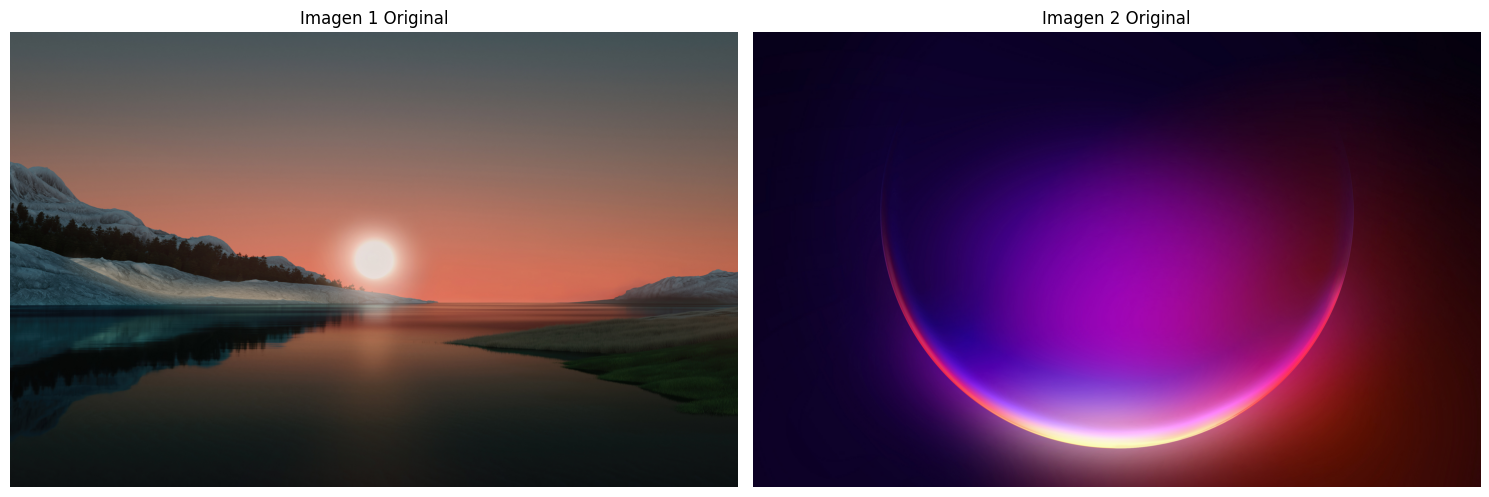

In [3]:
# Cargar las dos imágenes
img1 = cv2.imread('IMG/img1.jpg')
img2 = cv2.imread('IMG/img2.jpg')

# Verificar que se cargaron correctamente
if img1 is None or img2 is None:
    print('Error: No se pudieron cargar las imágenes')
else:
    print(f'img1 cargada: {img1.shape}')
    print(f'img2 cargada: {img2.shape}')
    
    # Mostrar imágenes originales
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Imagen 1 Original')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Imagen 2 Original')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## 3. Tarea 1: Establecer Fondo en Rojo, Azul y Verde

**Estrategia:** Usar umbralización para separar el objeto principal del fondo, luego aplicar colores al fondo.

**Técnicas usadas:**
- `cv2.cvtColor()` - Conversión a escala de grises
- `cv2.GaussianBlur()` - Suavizado (técnica de Detectar_colores.ipynb)
- `cv2.threshold()` con OTSU - Segmentación automática (técnica de Controno.ipynb)
- `cv2.bitwise_and()` - Operaciones con máscaras

Cambiando fondos de img1...


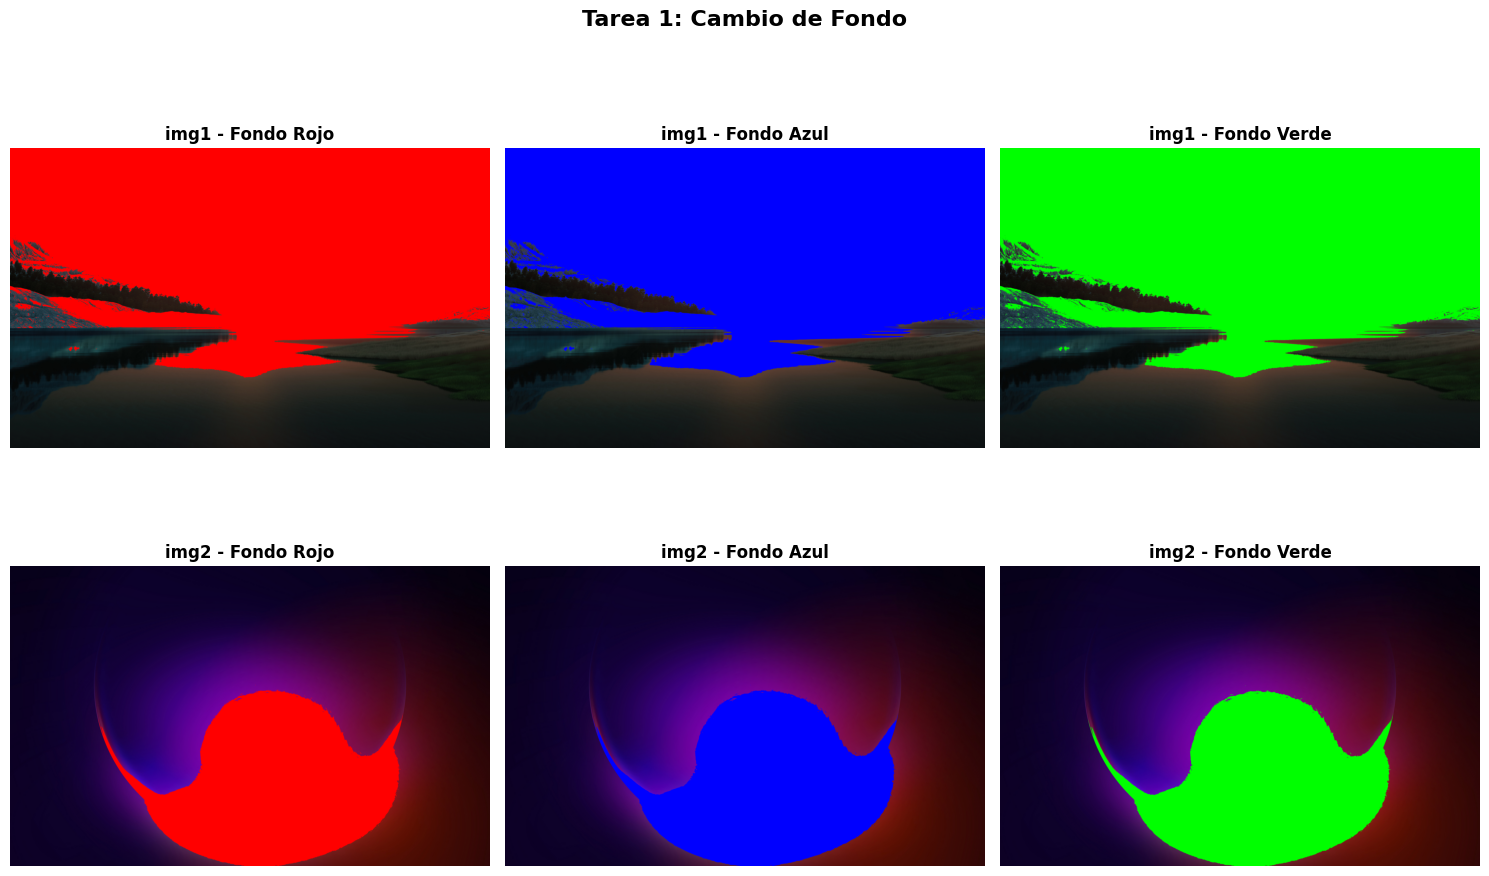

✓ Tarea 1 completada


In [4]:
def cambiar_fondo(img, color_nombre, color_bgr):
    """
    Cambia el fondo de una imagen a un color específico
    Args:
        img: Imagen BGR de entrada
        color_nombre: Nombre del color para el título
        color_bgr: Tupla (B, G, R) del color deseado
    Returns:
        Imagen con fondo cambiado
    """
    # Convertir a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Aplicar suavizado para reducir ruido (técnica de Detectar_colores.ipynb)
    gray_smooth = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Umbralización con Otsu para separar objeto del fondo
    _, mask = cv2.threshold(gray_smooth, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Crear imagen de fondo con el color deseado
    fondo = np.full_like(img, color_bgr, dtype=np.uint8)
    
    # Invertir máscara para obtener el objeto
    mask_inv = cv2.bitwise_not(mask)
    
    # Extraer objeto de la imagen original
    objeto = cv2.bitwise_and(img, img, mask=mask_inv)
    
    # Extraer fondo coloreado
    fondo_coloreado = cv2.bitwise_and(fondo, fondo, mask=mask)
    
    # Combinar objeto con fondo coloreado
    resultado = cv2.add(objeto, fondo_coloreado)
    
    return resultado

# Definir colores en formato BGR (OpenCV trabaja en BGR)
colores = {
    'Rojo': (0, 0, 255),
    'Azul': (255, 0, 0),
    'Verde': (0, 255, 0)
}

# Aplicar a img1
print('Cambiando fondos de img1...')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Tarea 1: Cambio de Fondo', fontsize=16, fontweight='bold')

for idx, (nombre, color) in enumerate(colores.items()):
    resultado = cambiar_fondo(img1, nombre, color)
    axes[0, idx].imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    axes[0, idx].set_title(f'img1 - Fondo {nombre}', fontweight='bold')
    axes[0, idx].axis('off')

# Aplicar a img2
for idx, (nombre, color) in enumerate(colores.items()):
    resultado = cambiar_fondo(img2, nombre, color)
    axes[1, idx].imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    axes[1, idx].set_title(f'img2 - Fondo {nombre}', fontweight='bold')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()
print('✓ Tarea 1 completada')

## 4. Tarea 2: Convertir a Escala de Grises

**Técnica:** `cv2.cvtColor()` con `COLOR_BGR2GRAY` (técnica de General.ipynb)

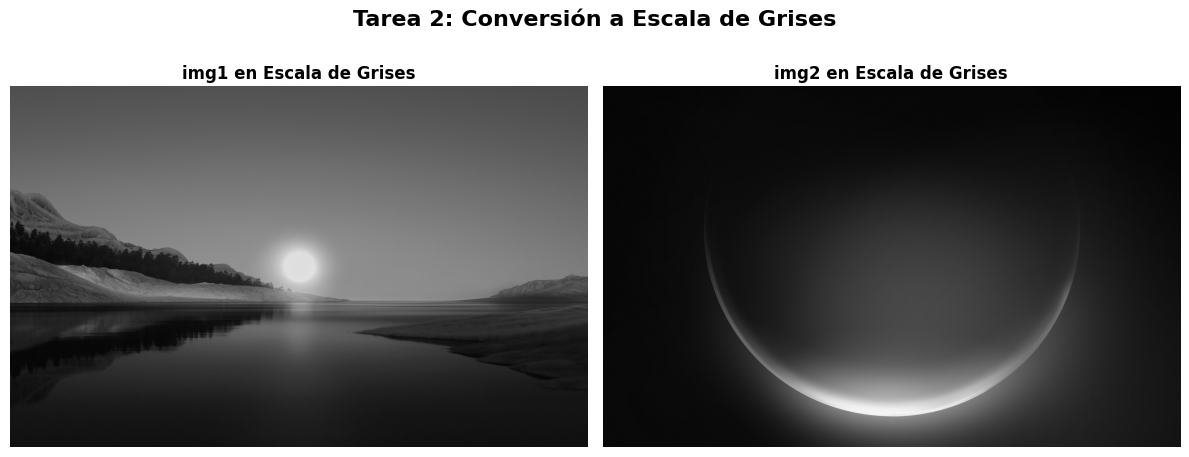

img1_gray shape: (4000, 6400)
img2_gray shape: (2400, 3840)
✓ Tarea 2 completada


In [5]:
# Conversión a escala de grises (técnica de General.ipynb)
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Tarea 2: Conversión a Escala de Grises', fontsize=16, fontweight='bold')

axes[0].imshow(img1_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('img1 en Escala de Grises', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img2_gray, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img2 en Escala de Grises', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'img1_gray shape: {img1_gray.shape}')
print(f'img2_gray shape: {img2_gray.shape}')
print('✓ Tarea 2 completada')

## 5. Tarea 3: Convertir de BGR a RGB

**Explicación:** OpenCV carga imágenes en formato BGR (Blue-Green-Red). Para visualizar correctamente con matplotlib, debemos convertir a RGB (Red-Green-Blue).

**Técnica:** `cv2.cvtColor()` con `COLOR_BGR2RGB` (técnica de General.ipynb)

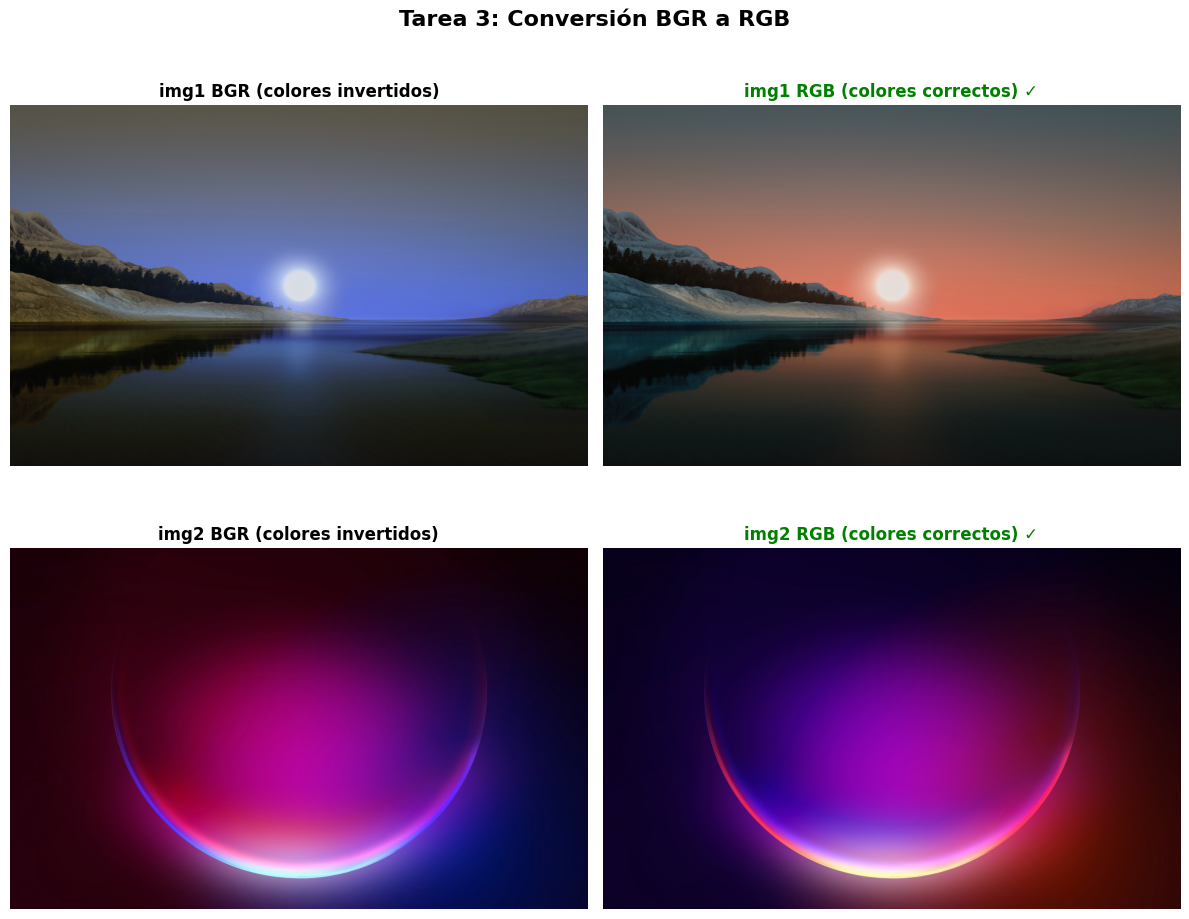

Nota: OpenCV carga imágenes en formato BGR.
Para visualizar correctamente con matplotlib, se debe convertir a RGB.
✓ Tarea 3 completada


In [6]:
# Conversión de BGR a RGB (técnica de General.ipynb)
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Visualizar comparación BGR vs RGB
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Tarea 3: Conversión BGR a RGB', fontsize=16, fontweight='bold')

# img1 - BGR (colores incorrectos en matplotlib)
axes[0, 0].imshow(img1)
axes[0, 0].set_title('img1 BGR (colores invertidos)', fontweight='bold')
axes[0, 0].axis('off')

# img1 - RGB (colores correctos)
axes[0, 1].imshow(img1_rgb)
axes[0, 1].set_title('img1 RGB (colores correctos) ✓', fontweight='bold', color='green')
axes[0, 1].axis('off')

# img2 - BGR
axes[1, 0].imshow(img2)
axes[1, 0].set_title('img2 BGR (colores invertidos)', fontweight='bold')
axes[1, 0].axis('off')

# img2 - RGB
axes[1, 1].imshow(img2_rgb)
axes[1, 1].set_title('img2 RGB (colores correctos) ✓', fontweight='bold', color='green')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print('Nota: OpenCV carga imágenes en formato BGR.')
print('Para visualizar correctamente con matplotlib, se debe convertir a RGB.')
print('✓ Tarea 3 completada')

## 6. Tarea 4: Establecer Umbral Óptimo

**Objetivo:**
- img1: El umbral debe resaltar el sol claramente
- img2: El umbral debe resaltar el contorno circular

**Técnicas:**
- `cv2.GaussianBlur()` - Suavizado previo (técnica de Suavizados.ipynb)
- `cv2.threshold()` con método OTSU - Cálculo automático del umbral óptimo (técnica de Controno.ipynb)

**Justificación de OTSU:** El método OTSU analiza el histograma de la imagen y calcula automáticamente el valor de umbral que mejor separa los píxeles en dos clases (objeto y fondo), minimizando la varianza intra-clase.

Umbral óptimo para img1 (sol): 70.00
Explicación: OTSU calcula automáticamente el valor que mejor separa el sol del resto de la imagen

Umbral óptimo para img2 (círculo): 55.00
Explicación: OTSU automáticamente encuentra el mejor umbral para segmentar el objeto circular


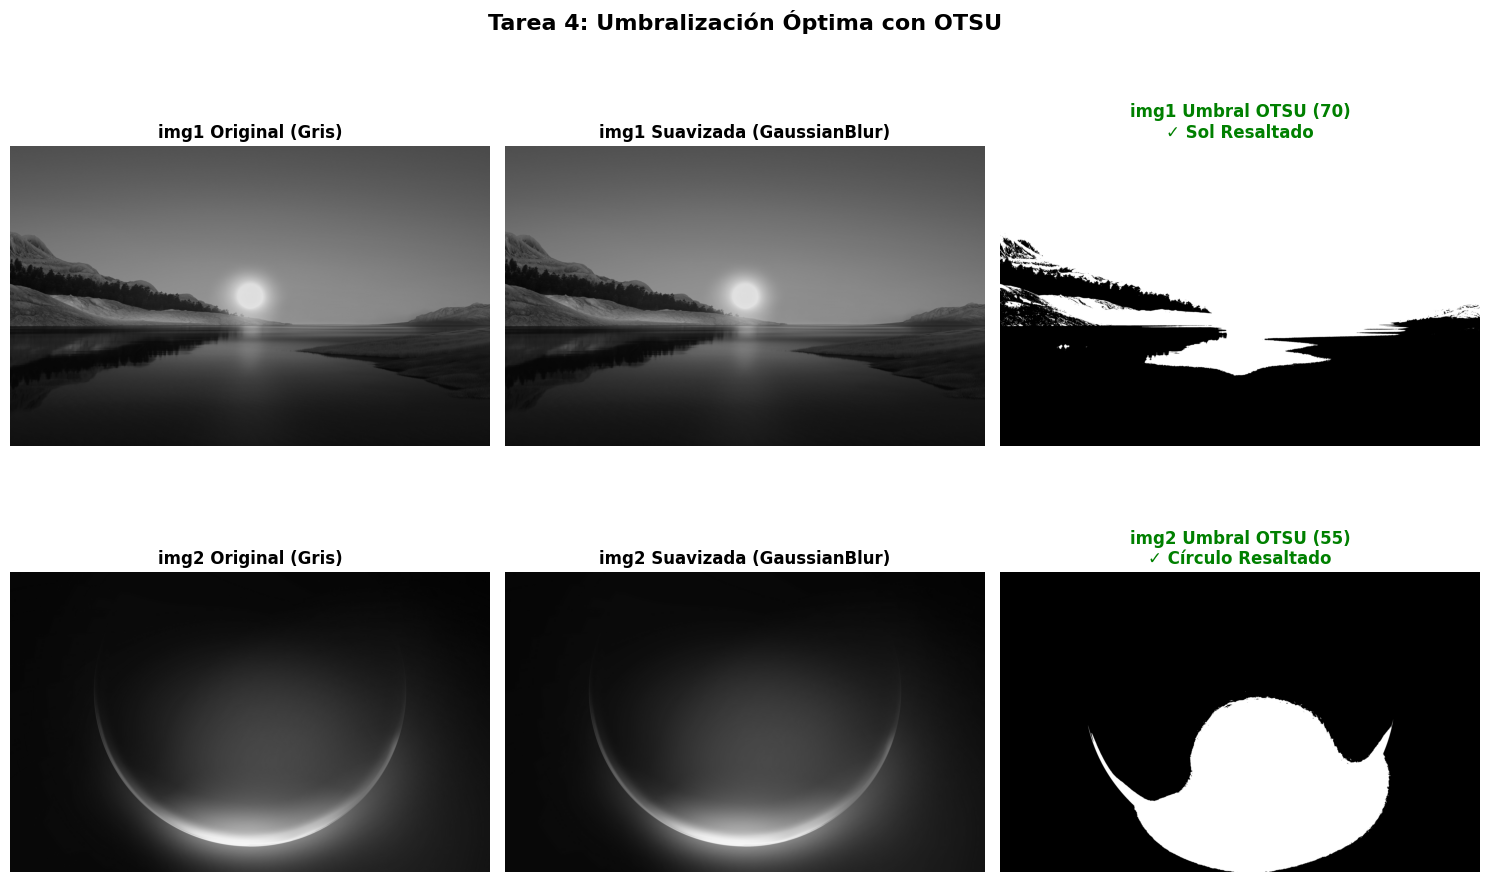

✓ Tarea 4 completada


In [7]:
# Para img1: Resaltar el sol (objeto brillante)
# Aplicar suavizado primero (técnica de Suavizados.ipynb)
img1_smooth = cv2.GaussianBlur(img1_gray, (5, 5), 0)

# Umbral con OTSU para detectar áreas brillantes (el sol)
# Usamos BINARY para mantener las áreas claras
umbral1_valor, img1_umbral = cv2.threshold(img1_smooth, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f'Umbral óptimo para img1 (sol): {umbral1_valor:.2f}')
print('Explicación: OTSU calcula automáticamente el valor que mejor separa el sol del resto de la imagen')

# Para img2: Resaltar el contorno circular
img2_smooth = cv2.GaussianBlur(img2_gray, (5, 5), 0)

# Umbral con OTSU
umbral2_valor, img2_umbral = cv2.threshold(img2_smooth, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f'\nUmbral óptimo para img2 (círculo): {umbral2_valor:.2f}')
print('Explicación: OTSU automáticamente encuentra el mejor umbral para segmentar el objeto circular')

# Visualizar resultados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Tarea 4: Umbralización Óptima con OTSU', fontsize=16, fontweight='bold')

# img1
axes[0, 0].imshow(img1_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('img1 Original (Gris)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img1_smooth, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('img1 Suavizada (GaussianBlur)', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(img1_umbral, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title(f'img1 Umbral OTSU ({umbral1_valor:.0f})\n✓ Sol Resaltado', fontweight='bold', color='green')
axes[0, 2].axis('off')

# img2
axes[1, 0].imshow(img2_gray, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('img2 Original (Gris)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img2_smooth, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('img2 Suavizada (GaussianBlur)', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(img2_umbral, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title(f'img2 Umbral OTSU ({umbral2_valor:.0f})\n✓ Círculo Resaltado', fontweight='bold', color='green')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
print('✓ Tarea 4 completada')

## 7. Tarea 5: Reducir Imagen a Tamaño 100 y Convertir a Grises

**Técnica:** `cv2.resize()` manteniendo proporción (técnica de General.ipynb)

img1 original: (4000, 6400, 3) -> reducida: (62, 100)
img2 original: (2400, 3840, 3) -> reducida: (62, 100)


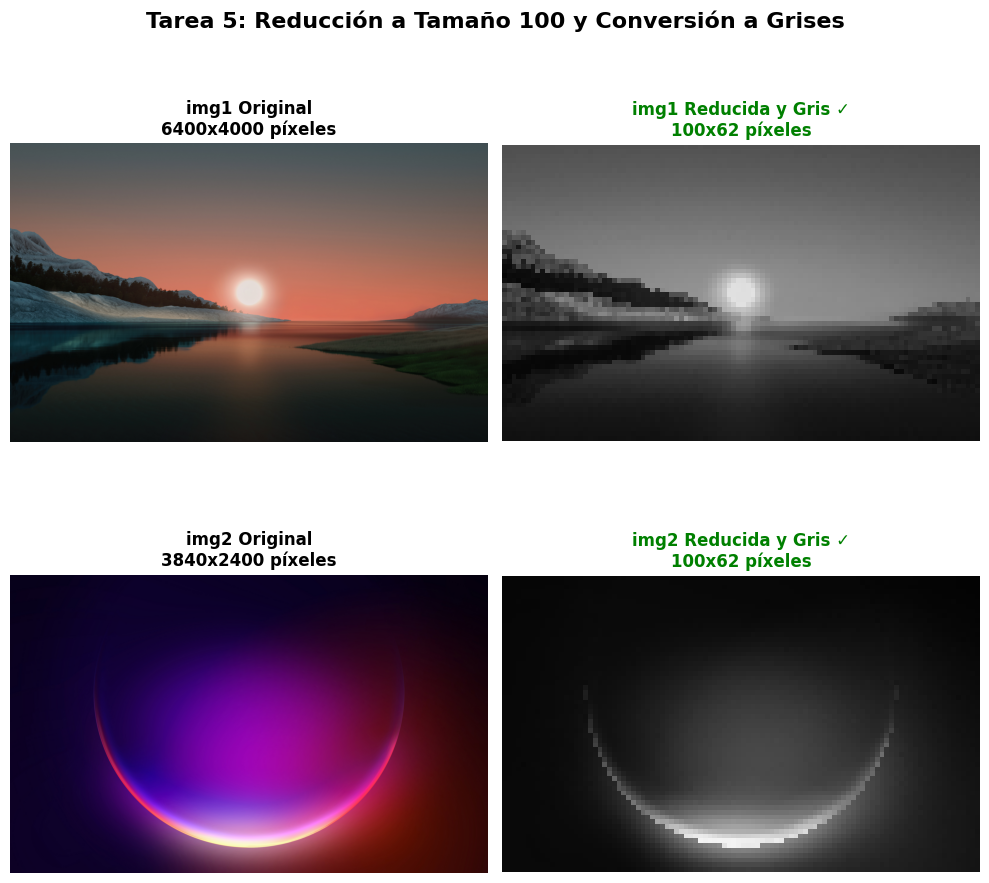

✓ Tarea 5 completada


In [8]:
# Reducir manteniendo proporción a tamaño máximo de 100 píxeles
# (técnica de redimensionamiento de General.ipynb)

def reducir_imagen(img, max_size=100):
    """
    Reduce una imagen manteniendo su proporción
    Args:
        img: Imagen de entrada
        max_size: Tamaño máximo del lado mayor
    Returns:
        Imagen redimensionada y en escala de grises
    """
    h, w = img.shape[:2]
    
    # Calcular nuevo tamaño manteniendo proporción
    if h > w:
        nuevo_h = max_size
        nuevo_w = int(w * (max_size / h))
    else:
        nuevo_w = max_size
        nuevo_h = int(h * (max_size / w))
    
    # Redimensionar
    img_reducida = cv2.resize(img, (nuevo_w, nuevo_h))
    
    # Convertir a grises si no lo está
    if len(img_reducida.shape) == 3:
        img_reducida_gray = cv2.cvtColor(img_reducida, cv2.COLOR_BGR2GRAY)
    else:
        img_reducida_gray = img_reducida
    
    return img_reducida_gray

# Aplicar reducción
img1_reducida = reducir_imagen(img1, max_size=100)
img2_reducida = reducir_imagen(img2, max_size=100)

print(f'img1 original: {img1.shape} -> reducida: {img1_reducida.shape}')
print(f'img2 original: {img2.shape} -> reducida: {img2_reducida.shape}')

# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Tarea 5: Reducción a Tamaño 100 y Conversión a Grises', fontsize=16, fontweight='bold')

# img1
axes[0, 0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f'img1 Original\n{img1.shape[1]}x{img1.shape[0]} píxeles', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img1_reducida, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title(f'img1 Reducida y Gris ✓\n{img1_reducida.shape[1]}x{img1_reducida.shape[0]} píxeles', fontweight='bold', color='green')
axes[0, 1].axis('off')

# img2
axes[1, 0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title(f'img2 Original\n{img2.shape[1]}x{img2.shape[0]} píxeles', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img2_reducida, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title(f'img2 Reducida y Gris ✓\n{img2_reducida.shape[1]}x{img2_reducida.shape[0]} píxeles', fontweight='bold', color='green')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
print('✓ Tarea 5 completada')

## 8. Tarea 6: Establecer Fondo Rojo con Umbral

**Objetivo:** Usar umbralización para segmentar el objeto principal y colocar fondo rojo.

**Pipeline:**
1. Convertir a escala de grises
2. Aplicar suavizado GaussianBlur
3. Umbralización con OTSU
4. Crear máscara para separar objeto del fondo
5. Aplicar fondo rojo usando operaciones bitwise

img1 - Umbral OTSU: 71.00
img2 - Umbral OTSU: 55.00


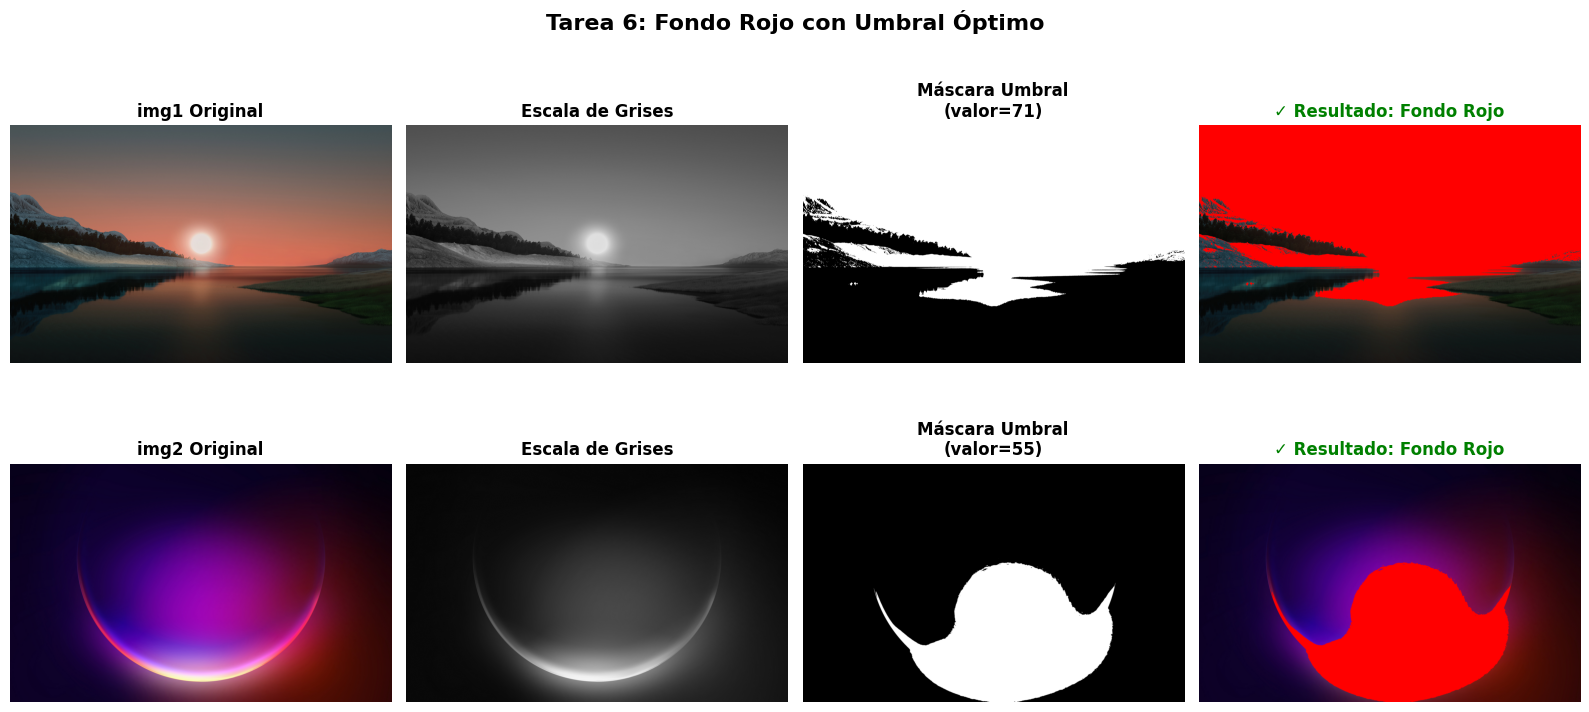

✓ Tarea 6 completada


In [9]:
def fondo_rojo_con_umbral(img, nombre_img):
    """
    Aplica umbral óptimo y establece fondo rojo
    Args:
        img: Imagen BGR de entrada
        nombre_img: Nombre para título
    Returns:
        Imagen con fondo rojo y umbral aplicado, máscara, valor de umbral
    """
    # Convertir a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Suavizado para mejorar umbralización
    gray_smooth = cv2.GaussianBlur(gray, (7, 7), 0)
    
    # Umbralización con OTSU
    umbral_valor, mask = cv2.threshold(gray_smooth, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    print(f'{nombre_img} - Umbral OTSU: {umbral_valor:.2f}')
    
    # Crear fondo rojo
    fondo_rojo = np.zeros_like(img)
    fondo_rojo[:, :] = (0, 0, 255)  # BGR: Rojo
    
    # Invertir máscara para obtener el objeto
    mask_inv = cv2.bitwise_not(mask)
    
    # Extraer objeto
    objeto = cv2.bitwise_and(img, img, mask=mask_inv)
    
    # Extraer fondo rojo
    fondo = cv2.bitwise_and(fondo_rojo, fondo_rojo, mask=mask)
    
    # Combinar
    resultado = cv2.add(objeto, fondo)
    
    return resultado, mask, umbral_valor

# Aplicar a ambas imágenes
img1_fondo_rojo, img1_mask, umbral1 = fondo_rojo_con_umbral(img1, 'img1')
img2_fondo_rojo, img2_mask, umbral2 = fondo_rojo_con_umbral(img2, 'img2')

# Visualizar proceso completo
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Tarea 6: Fondo Rojo con Umbral Óptimo', fontsize=16, fontweight='bold')

# img1 - proceso
axes[0, 0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('img1 Original', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Escala de Grises', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(img1_mask, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title(f'Máscara Umbral\n(valor={umbral1:.0f})', fontweight='bold')
axes[0, 2].axis('off')

axes[0, 3].imshow(cv2.cvtColor(img1_fondo_rojo, cv2.COLOR_BGR2RGB))
axes[0, 3].set_title('✓ Resultado: Fondo Rojo', fontweight='bold', color='green')
axes[0, 3].axis('off')

# img2 - proceso
axes[1, 0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('img2 Original', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Escala de Grises', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(img2_mask, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title(f'Máscara Umbral\n(valor={umbral2:.0f})', fontweight='bold')
axes[1, 2].axis('off')

axes[1, 3].imshow(cv2.cvtColor(img2_fondo_rojo, cv2.COLOR_BGR2RGB))
axes[1, 3].set_title('✓ Resultado: Fondo Rojo', fontweight='bold', color='green')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()
print('✓ Tarea 6 completada')

## 9. Resumen de Técnicas Utilizadas

In [10]:
print('='*70)
print('RESUMEN DE TÉCNICAS OPENCV UTILIZADAS')
print('='*70)
print()
print('1. CARGA DE IMÁGENES:')
print('   - cv2.imread() - Cargar imágenes desde archivo')
print()
print('2. CONVERSIÓN DE COLORES:')
print('   - cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) - BGR a Escala de Grises')
print('   - cv2.cvtColor(img, cv2.COLOR_BGR2RGB) - BGR a RGB para matplotlib')
print()
print('3. SUAVIZADO (reducción de ruido):')
print('   - cv2.GaussianBlur(img, (5,5), 0) - Filtro Gaussiano')
print('   - Aplicado antes de umbralización para mejores resultados')
print()
print('4. UMBRALIZACIÓN:')
print('   - cv2.threshold() con THRESH_BINARY + THRESH_OTSU')
print('   - OTSU calcula automáticamente el valor óptimo de umbral')
print('   - Separa objetos del fondo basándose en intensidad')
print()
print('5. OPERACIONES CON MÁSCARAS:')
print('   - cv2.bitwise_and() - Aplicar máscara a imagen')
print('   - cv2.bitwise_not() - Invertir máscara')
print('   - cv2.add() - Combinar objeto con fondo')
print()
print('6. REDIMENSIONAMIENTO:')
print('   - cv2.resize(img, (width, height)) - Cambiar tamaño')
print('   - Mantener proporción calculando relación de aspecto')
print()
print('7. VISUALIZACIÓN:')
print('   - matplotlib.pyplot para mostrar múltiples imágenes')
print('   - subplot() para organizar visualizaciones')
print('='*70)
print()
print('✓ TODAS LAS TAREAS COMPLETADAS EXITOSAMENTE')
print()
print('Técnicas basadas en:')
print('  - Suavizados.ipynb (GaussianBlur, medianBlur)')
print('  - Controno.ipynb (threshold con OTSU)')
print('  - Detectar_colores.ipynb (máscaras y segmentación)')
print('  - General.ipynb (conversiones de color y visualización)')
print('='*70)

RESUMEN DE TÉCNICAS OPENCV UTILIZADAS

1. CARGA DE IMÁGENES:
   - cv2.imread() - Cargar imágenes desde archivo

2. CONVERSIÓN DE COLORES:
   - cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) - BGR a Escala de Grises
   - cv2.cvtColor(img, cv2.COLOR_BGR2RGB) - BGR a RGB para matplotlib

3. SUAVIZADO (reducción de ruido):
   - cv2.GaussianBlur(img, (5,5), 0) - Filtro Gaussiano
   - Aplicado antes de umbralización para mejores resultados

4. UMBRALIZACIÓN:
   - cv2.threshold() con THRESH_BINARY + THRESH_OTSU
   - OTSU calcula automáticamente el valor óptimo de umbral
   - Separa objetos del fondo basándose en intensidad

5. OPERACIONES CON MÁSCARAS:
   - cv2.bitwise_and() - Aplicar máscara a imagen
   - cv2.bitwise_not() - Invertir máscara
   - cv2.add() - Combinar objeto con fondo

6. REDIMENSIONAMIENTO:
   - cv2.resize(img, (width, height)) - Cambiar tamaño
   - Mantener proporción calculando relación de aspecto

7. VISUALIZACIÓN:
   - matplotlib.pyplot para mostrar múltiples imágenes
   - subplo

## 10. Guardar Resultados (Opcional)

In [11]:
# Guardar algunos resultados clave
cv2.imwrite('IMG/img1_fondo_rojo.jpg', img1_fondo_rojo)
cv2.imwrite('IMG/img2_fondo_rojo.jpg', img2_fondo_rojo)
cv2.imwrite('IMG/img1_umbral.jpg', img1_umbral)
cv2.imwrite('IMG/img2_umbral.jpg', img2_umbral)
cv2.imwrite('IMG/img1_reducida.jpg', img1_reducida)
cv2.imwrite('IMG/img2_reducida.jpg', img2_reducida)

print('✓ Resultados guardados en carpeta IMG/')
print('  - img1_fondo_rojo.jpg')
print('  - img2_fondo_rojo.jpg')
print('  - img1_umbral.jpg')
print('  - img2_umbral.jpg')
print('  - img1_reducida.jpg')
print('  - img2_reducida.jpg')

✓ Resultados guardados en carpeta IMG/
  - img1_fondo_rojo.jpg
  - img2_fondo_rojo.jpg
  - img1_umbral.jpg
  - img2_umbral.jpg
  - img1_reducida.jpg
  - img2_reducida.jpg
